In [12]:
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

sns.set_theme(style="whitegrid")

conn = sqlite3.connect("dsl.db")

from dsl_statistics.db import RANK_NAMES

In [13]:
# Get latest stats per player (most recent snapshot)
players_df = pd.read_sql("""
    SELECT
        p.id as player_id, p.display_name, p.steam_account_id,
        p.first_game_at, p.steam_account_created, p.steam_games_owned,
        p.steam_profile_visible,
        d.name as division, t.name as team,
        tm.role, tm.is_poc,
        ps.pp_score, ps.rank_number, ps.rank_subrank, ps.scraped_at
    FROM players p
    JOIN team_members tm ON p.id = tm.player_id AND tm.left_at IS NULL
    JOIN teams t ON tm.team_id = t.id
    JOIN divisions d ON t.division_id = d.id
    LEFT JOIN player_stats ps ON p.id = ps.player_id
        AND ps.scraped_at = (
            SELECT MAX(ps2.scraped_at) FROM player_stats ps2 WHERE ps2.player_id = p.id
        )
    ORDER BY d.name, t.name, p.display_name
""", conn)

players_df["rank_label"] = players_df["rank_number"].map(RANK_NAMES)
print(f"Loaded {len(players_df)} active players across {players_df['division'].nunique()} divisions")
players_df.head()

Loaded 801 active players across 5 divisions


,player_id,display_name,steam_account_id,first_game_at,steam_account_created,steam_games_owned,steam_profile_visible,division,team,role,is_poc,pp_score,rank_number,rank_subrank,scraped_at,rank_label
0,322,.twilley. (Jake),1120747002,None,2020-08-09T01:22:20+00:00,113.0,1,Division 1,100 IQ,core,1,6411.0,11,4,2026-04-18 07:06:06,Eternus
1,323,chikiaf,1127527955,None,2020-09-03T06:06:16+00:00,NaN,1,Division 1,100 IQ,core,0,5434.0,9,6,2026-04-18 07:06:11,Phantom
2,324,fruiwt (fruiwt),876989902,None,2018-05-22T22:32:46+00:00,124.0,1,Division 1,100 IQ,core,0,3286.0,6,2,2026-04-18 07:06:16,Emissary
3,325,jstn7. (mungy),416994670,None,NaN,NaN,0,Division 1,100 IQ,core,0,5743.0,10,3,2026-04-18 07:06:22,Ascendant
4,326,me_sushi (meesushii),1030495599,None,2019-09-14T23:00:41+00:00,36.0,1,Division 1,100 IQ,core,0,6707.0,11,6,2026-04-18 07:06:29,Eternus


In [14]:
div_stats = players_df.groupby("division")["pp_score"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(1)
div_stats.columns = ["Players", "Avg PP", "Median PP", "Std Dev", "Min PP", "Max PP"]
print("=== Division Overview ===")
div_stats

=== Division Overview ===


,Players,Avg PP,Median PP,Std Dev,Min PP,Max PP
division,,,,,,
Division 1,200,6005.7,6078.0,461.4,3286.0,6849.0
Division 2,203,5417.0,5477.0,584.3,3542.0,6716.0
Division 3,172,4525.2,4604.0,891.3,1133.0,6241.0
Division 4,108,3183.0,3213.0,1024.7,1034.0,5967.0
Premier Division,118,6293.3,6337.0,275.9,5602.0,7211.0


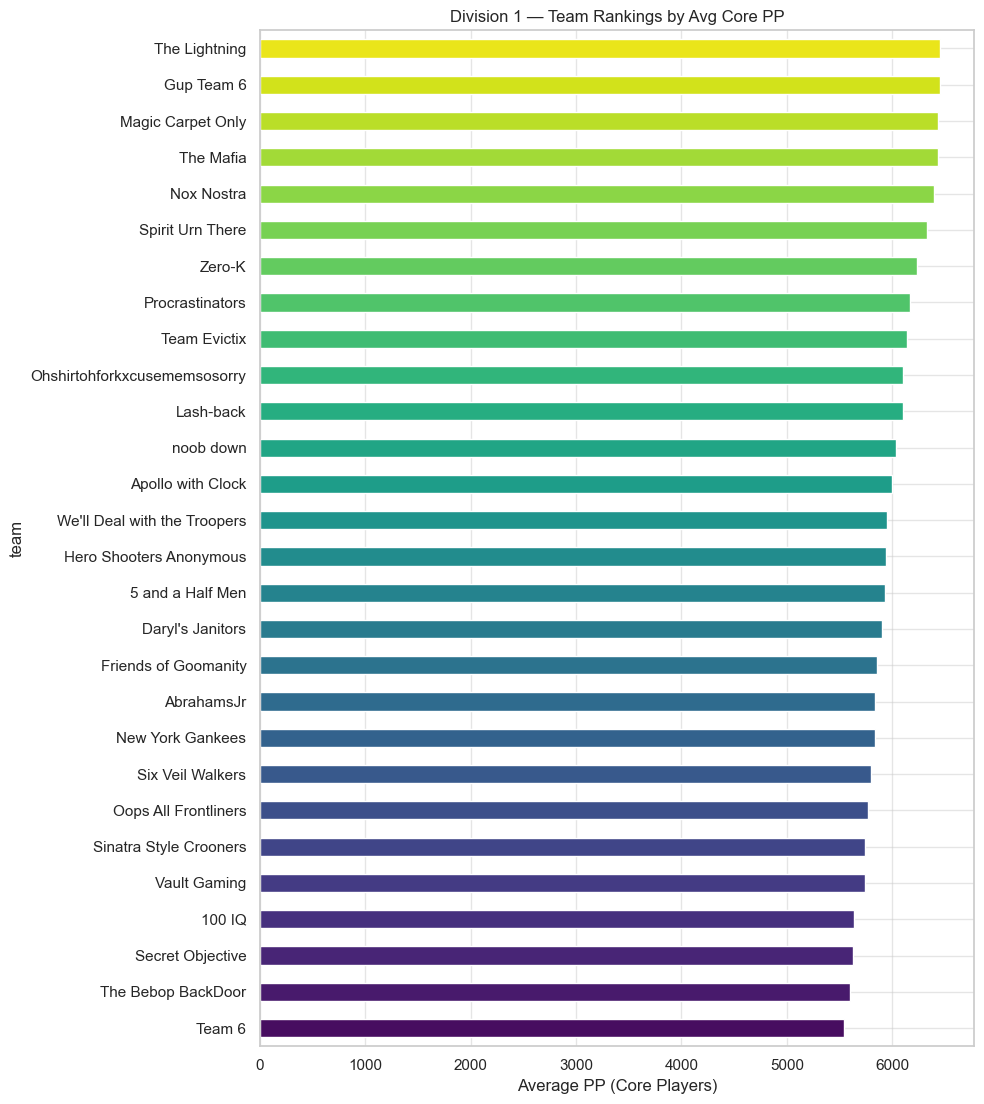

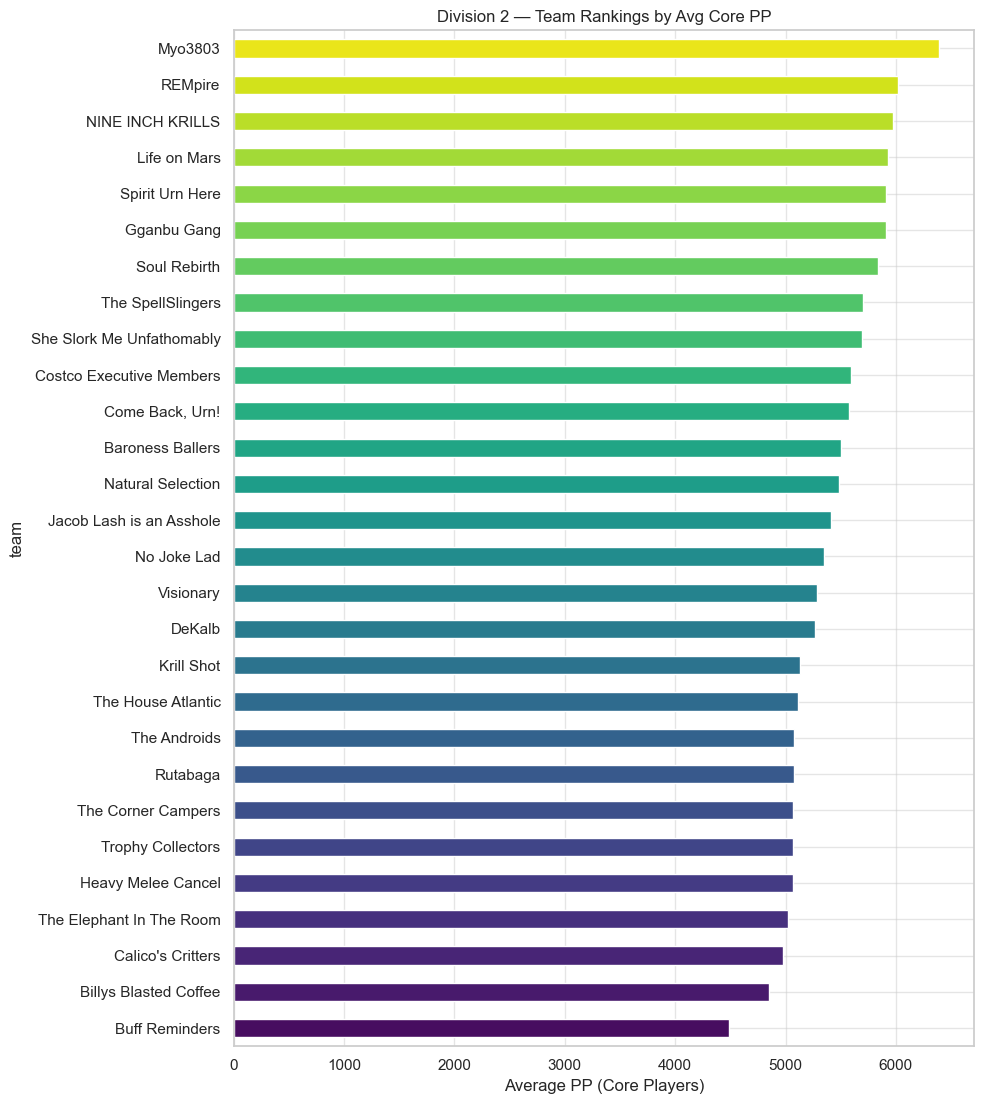

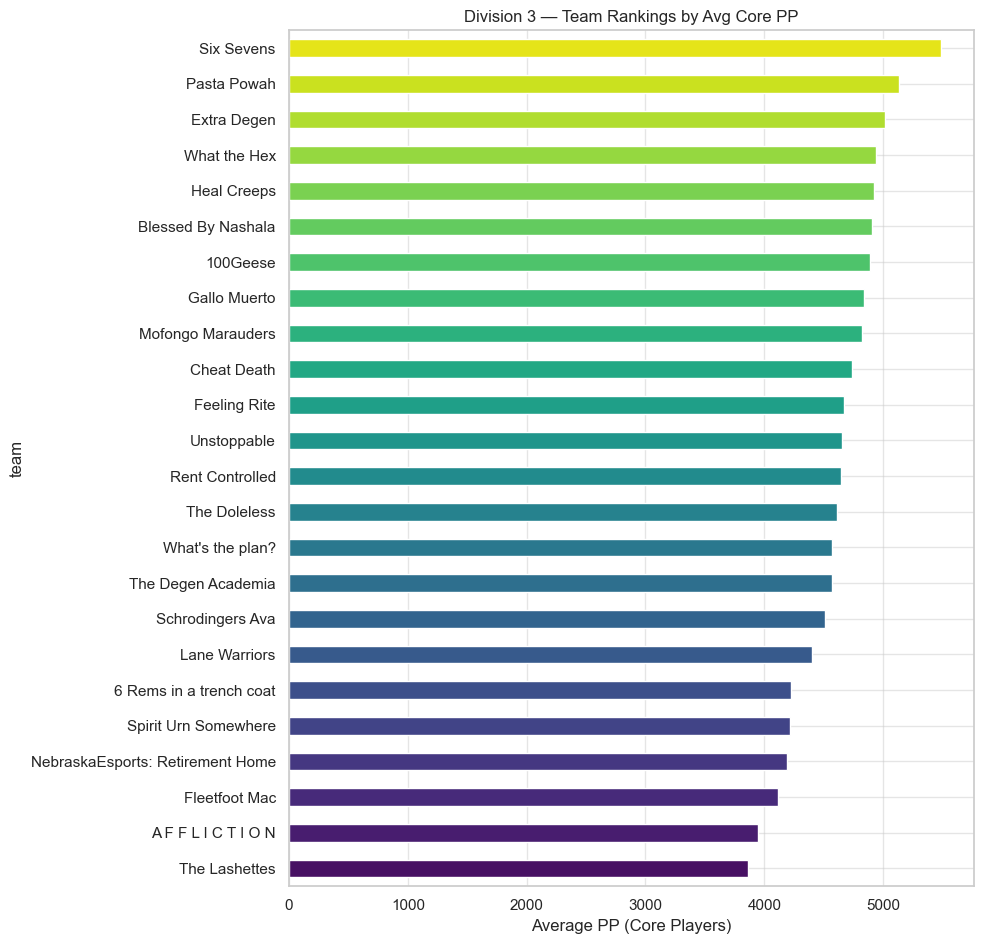

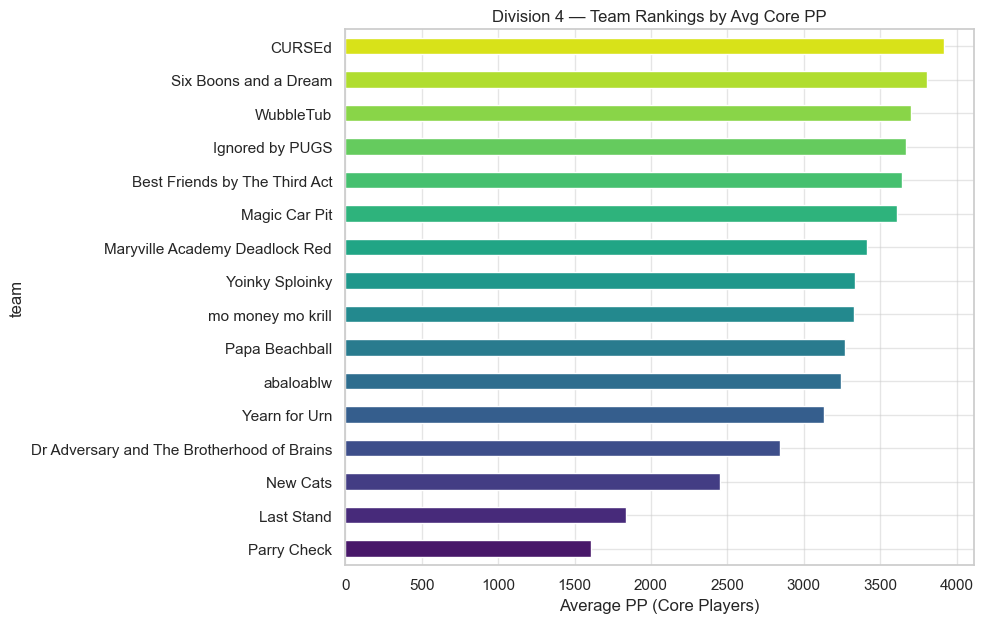

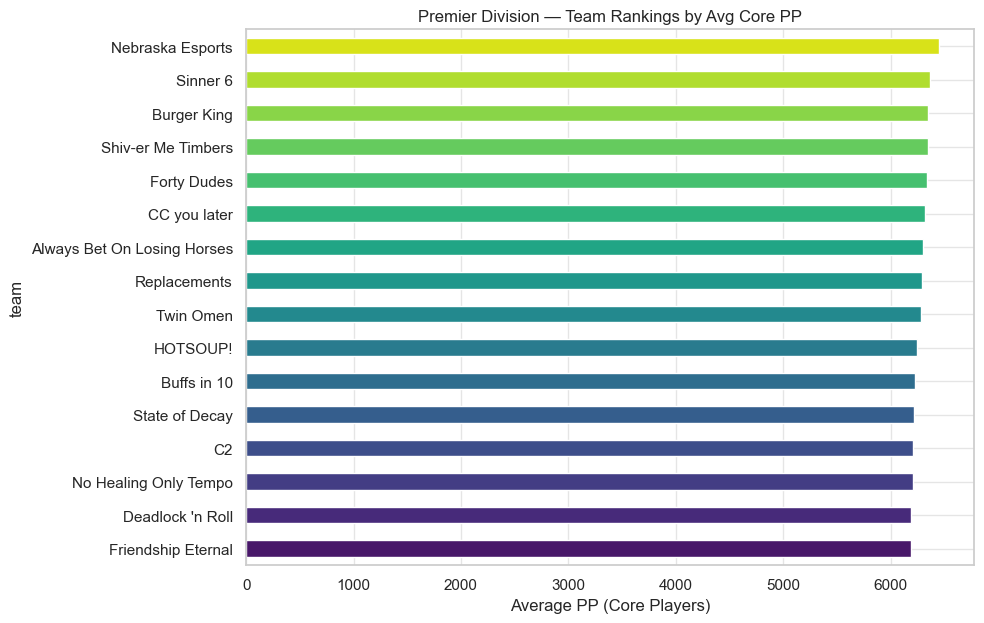

In [15]:
# Average PP of core players per team
core_players = players_df[players_df["role"] == "core"]
team_rankings = core_players.groupby(["division", "team"])["pp_score"].agg(
    ["mean", "count"]
).round(1)
team_rankings.columns = ["Avg Core PP", "Core Players"]
team_rankings = team_rankings.sort_values(["Avg Core PP"], ascending=False)

for div in sorted(players_df["division"].unique()):
    div_teams = team_rankings.loc[div].sort_values("Avg Core PP", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(div_teams) * 0.4)))
    div_teams["Avg Core PP"].plot(
        kind="barh", ax=ax, color=sns.color_palette("viridis", len(div_teams))
    )
    ax.set_title(f"{div} — Team Rankings by Avg Core PP")
    ax.set_xlabel("Average PP (Core Players)")
    plt.tight_layout()
    plt.show()

In [16]:
team_pp = core_players.groupby(["division", "team"])["pp_score"].mean()

print("=== Outlier Teams (>1 std dev from division mean) ===\n")
for div in sorted(players_df["division"].unique()):
    div_team_pp = team_pp[div]
    mean = div_team_pp.mean()
    std = div_team_pp.std()
    outliers = div_team_pp[(div_team_pp > mean + std) | (div_team_pp < mean - std)]
    if len(outliers) > 0:
        print(f"{div} (mean={mean:.1f}, std={std:.1f}):")
        for team_name, pp in outliers.items():
            direction = "ABOVE" if pp > mean else "BELOW"
            print(f"  {team_name}: {pp:.1f} ({direction}, {abs(pp - mean)/std:.1f}σ)")
        print()

=== Outlier Teams (>1 std dev from division mean) ===

Division 1 (mean=5999.7, std=280.4):
  100 IQ: 5637.5 (BELOW, 1.3σ)
  Gup Team 6: 6449.7 (ABOVE, 1.6σ)
  Magic Carpet Only: 6430.7 (ABOVE, 1.5σ)
  Nox Nostra: 6393.7 (ABOVE, 1.4σ)
  Secret Objective: 5624.2 (BELOW, 1.3σ)
  Spirit Urn There: 6326.7 (ABOVE, 1.2σ)
  Team 6: 5541.4 (BELOW, 1.6σ)
  The Bebop BackDoor: 5599.3 (BELOW, 1.4σ)
  The Lightning: 6452.7 (ABOVE, 1.6σ)
  The Mafia: 6429.3 (ABOVE, 1.5σ)

Division 2 (mean=5420.2, std=435.3):
  Billys Blasted Coffee: 4850.2 (BELOW, 1.3σ)
  Buff Reminders: 4490.7 (BELOW, 2.1σ)
  Calico's Critters: 4981.5 (BELOW, 1.0σ)
  Gganbu Gang: 5909.7 (ABOVE, 1.1σ)
  Life on Mars: 5927.8 (ABOVE, 1.2σ)
  Myo3803: 6388.3 (ABOVE, 2.2σ)
  NINE INCH KRILLS: 5974.7 (ABOVE, 1.3σ)
  REMpire: 6015.3 (ABOVE, 1.4σ)
  Spirit Urn Here: 5914.8 (ABOVE, 1.1σ)

Division 3 (mean=4620.3, std=389.7):
  6 Rems in a trench coat: 4225.8 (BELOW, 1.0σ)
  A F F L I C T I O N: 3945.3 (BELOW, 1.7σ)
  Extra Degen: 5015.0 (A

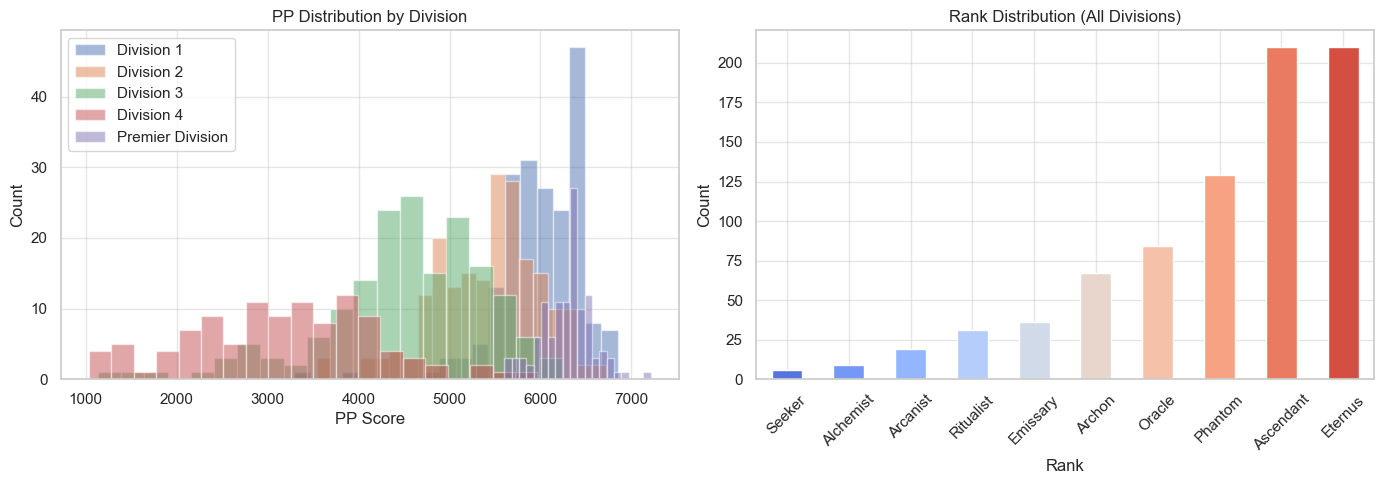

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PP histogram per division
for div in sorted(players_df["division"].unique()):
    div_data = players_df[players_df["division"] == div]["pp_score"].dropna()
    axes[0].hist(div_data, bins=20, alpha=0.5, label=div)
axes[0].set_title("PP Distribution by Division")
axes[0].set_xlabel("PP Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Rank distribution
rank_counts = players_df["rank_label"].value_counts()
rank_order = [RANK_NAMES[i] for i in range(12) if RANK_NAMES[i] in rank_counts.index]
rank_counts = rank_counts.reindex(rank_order)
rank_counts.plot(
    kind="bar", ax=axes[1], color=sns.color_palette("coolwarm", len(rank_counts))
)
axes[1].set_title("Rank Distribution (All Divisions)")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [18]:
def scout_player(player_name: str):
    """Display scouting info for a player."""
    player = players_df[
        players_df["display_name"].str.contains(player_name, case=False)
    ]
    if player.empty:
        print(f"Player '{player_name}' not found")
        return

    p = player.iloc[0]
    print(f"=== {p['display_name']} ===")
    print(f"Team: {p['team']} ({p['division']})")
    print(f"Role: {p['role']}{'  [POC]' if p['is_poc'] else ''}")
    print(f"PP: {p['pp_score']:.1f}")
    print(f"Rank: {p['rank_label']} {p['rank_subrank']}")
    print(f"Steam Account Age: {p['steam_account_created'] or 'Unknown'}")
    print(f"Games Owned: {p['steam_games_owned'] or 'Unknown'}")
    print()

    # Top heroes
    heroes = pd.read_sql("""
        SELECT ph.hero_name, ph.matches_played, ph.win_rate
        FROM player_heroes ph
        JOIN player_stats ps ON ph.stats_id = ps.id
        WHERE ps.player_id = ?
        AND ps.scraped_at = (SELECT MAX(scraped_at) FROM player_stats WHERE player_id = ?)
        ORDER BY ph.matches_played DESC
        LIMIT 10
    """, conn, params=(int(p["player_id"]), int(p["player_id"])))

    if not heroes.empty:
        print("Top Heroes:")
        for _, h in heroes.iterrows():
            print(
                f"  {h['hero_name']}: {h['matches_played']} games, "
                f"{h['win_rate']*100:.0f}% WR"
            )

    # PP trend from match history
    matches = pd.read_sql("""
        SELECT match_date, pp_after, pp_change, hero_name, result
        FROM player_matches
        WHERE player_id = ?
        ORDER BY match_date DESC
        LIMIT 20
    """, conn, params=(int(p["player_id"]),))

    if not matches.empty and matches["pp_after"].notna().any():
        fig, ax = plt.subplots(figsize=(10, 4))
        matches_sorted = matches.sort_values("match_date")
        colors = [
            "green" if r == "win" else "red" for r in matches_sorted["result"]
        ]
        ax.plot(
            range(len(matches_sorted)),
            matches_sorted["pp_after"],
            marker="o",
            color="steelblue",
        )
        ax.scatter(
            range(len(matches_sorted)),
            matches_sorted["pp_after"],
            c=colors,
            zorder=5,
        )
        ax.set_title(f"{p['display_name']} — Recent PP Trend")
        ax.set_xlabel("Match")
        ax.set_ylabel("PP")
        plt.tight_layout()
        plt.show()


# Example usage:
# scout_player("YourName")

/var/folders/v3/bc9r2tjd007_p6k0wp90_wqm0000gn/T/ipykernel_30846/410669927.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=div_order)


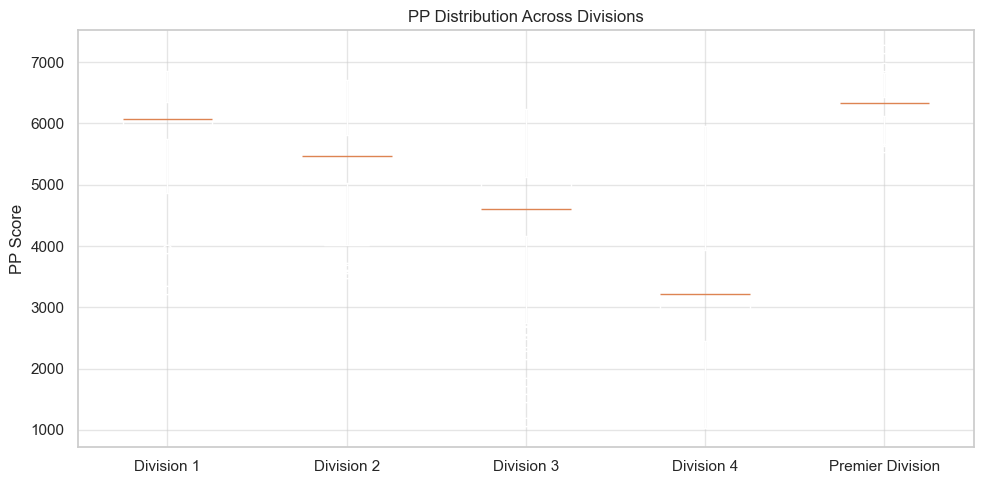

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
div_order = sorted(players_df["division"].unique())
data = [
    players_df[players_df["division"] == d]["pp_score"].dropna() for d in div_order
]
ax.boxplot(data, labels=div_order)
ax.set_title("PP Distribution Across Divisions")
ax.set_ylabel("PP Score")
plt.tight_layout()
plt.show()

/var/folders/v3/bc9r2tjd007_p6k0wp90_wqm0000gn/T/ipykernel_30846/830726079.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


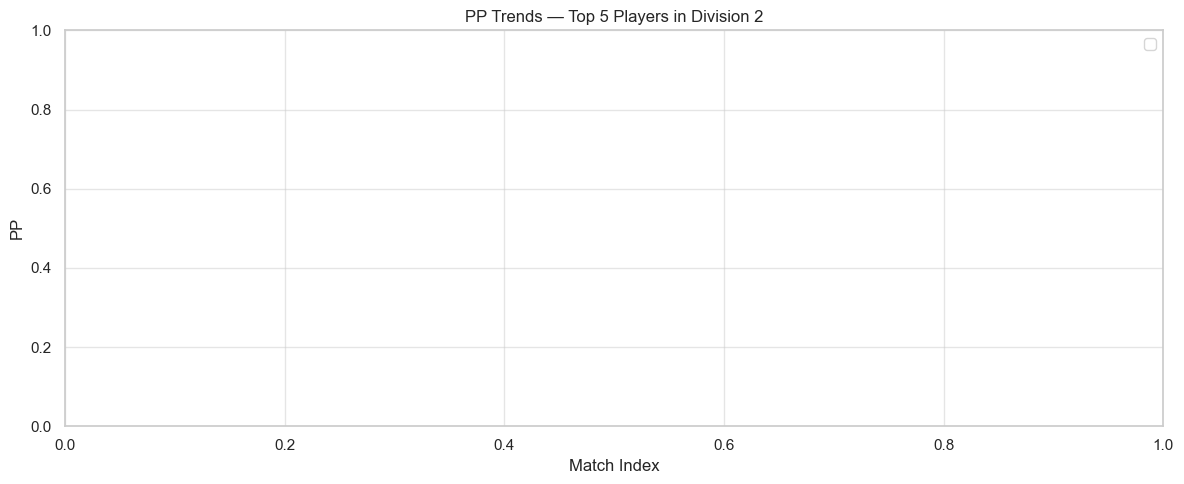

In [20]:
# PP trajectory from match history for top players in a division
my_division = "Division 2"  # Change as needed

div_players = players_df[players_df["division"] == my_division].nlargest(
    5, "pp_score"
)

fig, ax = plt.subplots(figsize=(12, 5))
for _, p in div_players.iterrows():
    matches = pd.read_sql("""
        SELECT match_date, pp_after FROM player_matches
        WHERE player_id = ? AND pp_after IS NOT NULL
        ORDER BY match_date
    """, conn, params=(int(p["player_id"]),))
    if not matches.empty:
        ax.plot(
            range(len(matches)),
            matches["pp_after"],
            label=p["display_name"],
            marker=".",
        )

ax.set_title(f"PP Trends — Top 5 Players in {my_division}")
ax.set_xlabel("Match Index")
ax.set_ylabel("PP")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [21]:
alt_flags = players_df[
    (players_df["pp_score"].notna())
    & (
        (players_df["steam_profile_visible"] == False)
        | (
            players_df["steam_games_owned"].notna()
            & (players_df["steam_games_owned"] < 10)
        )
        | (
            players_df["steam_account_created"].notna()
            & (
                pd.to_datetime(players_df["steam_account_created"], utc=True)
                > pd.Timestamp("2024-06-01", tz="UTC")
            )
        )
    )
].sort_values("pp_score", ascending=False)

print(f"=== Potential Alt Accounts ({len(alt_flags)} flagged) ===\n")
for _, p in alt_flags.iterrows():
    flags = []
    if p["steam_profile_visible"] == False:
        flags.append("PRIVATE PROFILE")
    if pd.notna(p["steam_games_owned"]) and p["steam_games_owned"] < 10:
        flags.append(f"ONLY {int(p['steam_games_owned'])} GAMES")
    if pd.notna(p["steam_account_created"]):
        created = pd.to_datetime(p["steam_account_created"], utc=True)
        if created > pd.Timestamp("2024-06-01", tz="UTC"):
            flags.append(f"ACCOUNT CREATED {created.strftime('%Y-%m')}")

    print(f"  {p['display_name']} ({p['team']}, {p['division']})")
    print(
        f"    PP: {p['pp_score']:.1f} | Rank: {p['rank_label']} | "
        f"Flags: {', '.join(flags)}"
    )

=== Potential Alt Accounts (125 flagged) ===

  awooga_dl (Awooga) (Forty Dudes, Premier Division)
    PP: 6798.0 | Rank: Eternus | Flags: ACCOUNT CREATED 2025-09
  jah1408 (GoongGong) (Sinner 6, Premier Division)
    PP: 6743.0 | Rank: Eternus | Flags: PRIVATE PROFILE
  saintfullyy (Saintfully) (Myo3803, Division 2)
    PP: 6716.0 | Rank: Eternus | Flags: ONLY 9 GAMES, ACCOUNT CREATED 2025-06
  lyth1k (The Mafia, Division 1)
    PP: 6673.0 | Rank: Eternus | Flags: PRIVATE PROFILE
  alejandro1013 (CC you later, Premier Division)
    PP: 6554.0 | Rank: Eternus | Flags: PRIVATE PROFILE
  ruincn (Andy) (Spirit Urn There, Division 1)
    PP: 6514.0 | Rank: Eternus | Flags: ACCOUNT CREATED 2024-11
  argentvm (Argent) (Sinner 6, Premier Division)
    PP: 6507.0 | Rank: Eternus | Flags: PRIVATE PROFILE
  masedog01 (Friends of Goomanity, Division 1)
    PP: 6446.0 | Rank: Eternus | Flags: PRIVATE PROFILE
  llosable (losable) (Myo3803, Division 2)
    PP: 6435.0 | Rank: Eternus | Flags: ACCOUNT

In [22]:
conn.close()